In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import load_breast_cancer

# Data splitting
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)

Dataset Shape: (569, 30)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=5000),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "SVM": SVC()

}

In [8]:
results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    print("------------------------------")

Logistic Regression
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

------------------------------
KNN
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        43
           1       0.93      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

------------------------------
Decision Tree
Accuracy: 0.9385964912280702
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.94      0.96      0.95        7

In [9]:
results_df = pd.DataFrame(list(results.items()),
                          columns=["Algorithm", "Accuracy"])

results_df

,Algorithm,Accuracy
0,Logistic Regression,0.956140
1,KNN,0.956140
2,Decision Tree,0.938596
3,Random Forest,0.964912
4,SVM,0.947368


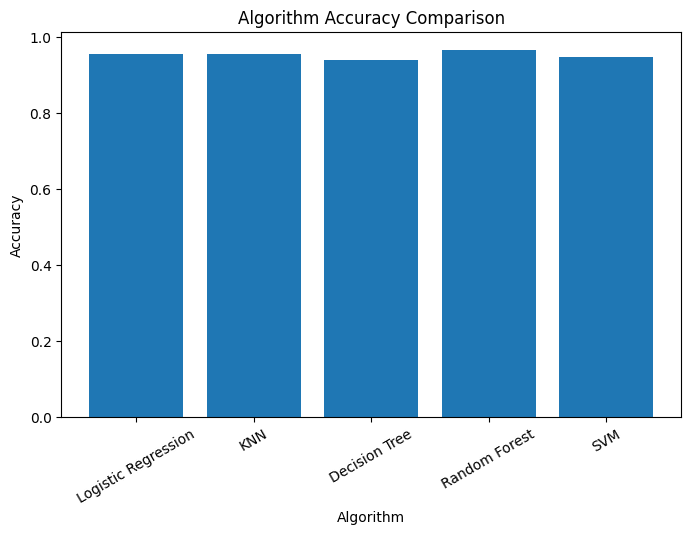

In [28]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Algorithm"],
        results_df["Accuracy"])

plt.title("Algorithm Accuracy Comparison")

plt.xlabel("Algorithm")

plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

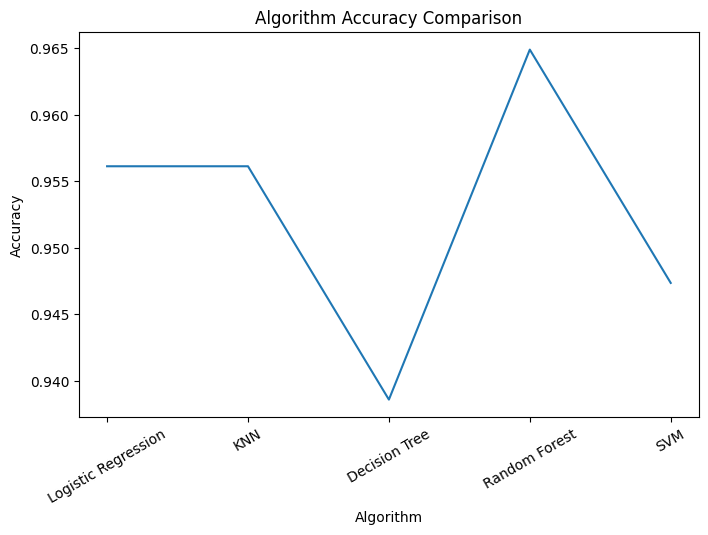

In [27]:
plt.figure(figsize=(8,5))
plt.plot(results_df["Algorithm"],
        results_df["Accuracy"])

plt.title("Algorithm Accuracy Comparison")

plt.xlabel("Algorithm")

plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

In [14]:
#print best model
best_model = max(results, key=results.get)
print("Best Model:", best_model)
print("Best Model Accuracy:", results[best_model])

Best Model: Random Forest
Best Model Accuracy: 0.9649122807017544


In [15]:
#train the best model
opt_model = RandomForestClassifier()
opt_model.fit(X_train, y_train)

RandomForestClassifier()

In [16]:
sample = X_test.iloc[0].values.reshape(1,-1)
sample_pred = opt_model.predict(sample)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [20]:
if sample_pred[0] == 1:
    print("Malignant (Cancer)")
else:
    print("Benign (No Cancer)")

Malignant (Cancer)
